In [2]:
from util import Runge
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

/mnt/c/users/sande/OneDrive - Universitetet i Oslo/Dokumenter/UiO/fysstk/P1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.389e-01, tolerance: 1.480e-03
  model = cd_fast.enet_coordinate_descent(
/mnt/c/users/sande/OneDrive - Universitetet i Oslo/Dokumenter/UiO/fysstk/P1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.744e-01, tolerance: 1.315e-03
  model = cd_fast.enet_coordinate_descent(
/mnt/c/users/sande/OneDrive - Universitetet i Oslo/Dokumenter/UiO/fysstk/P1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: 

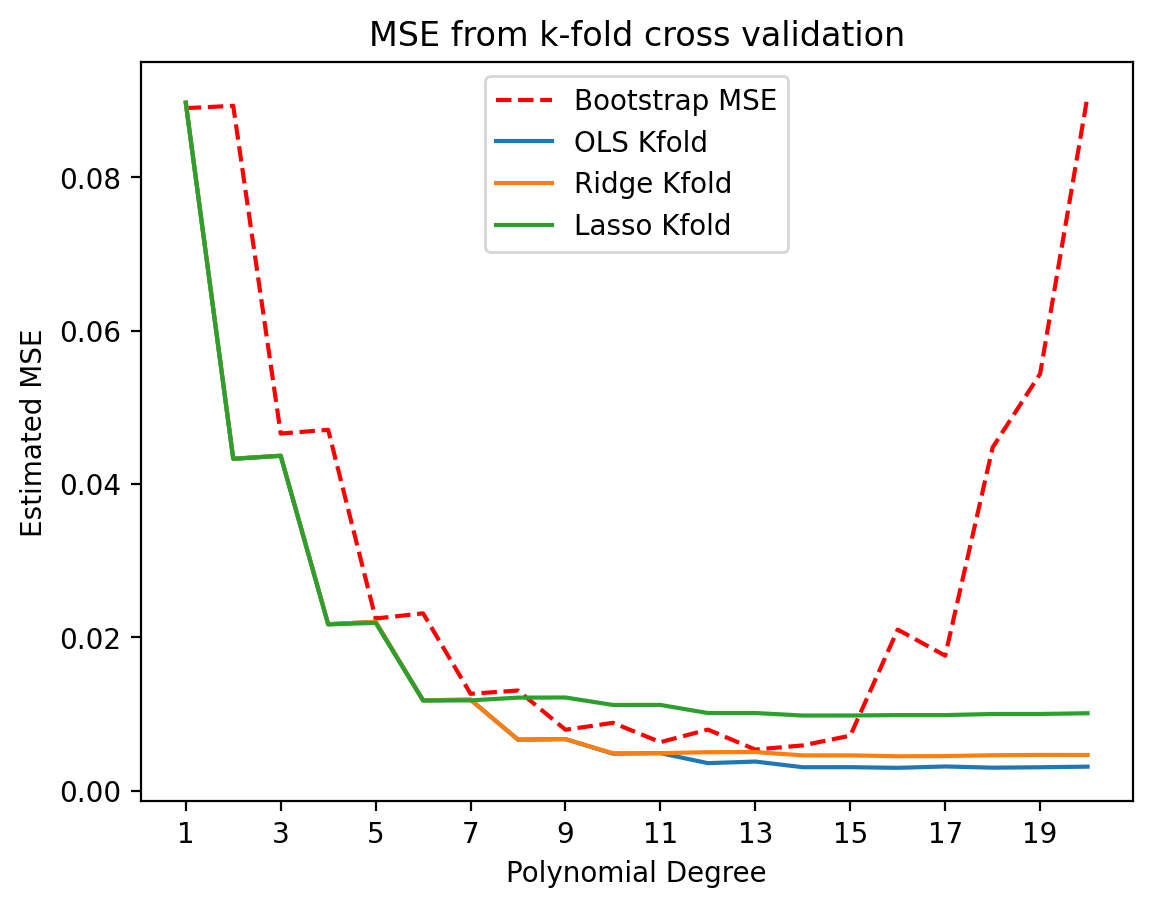

In [ ]:
n_points = 200
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
l = 1e-4

maxdegree = 20
degrees = np.arange(1, maxdegree + 1)

noise = 0.05 * np.random.randn(n_points,1)
x = np.linspace(-1, 1, n_points).reshape(-1,1)
y = Runge(x) + noise

estimated_mse_ols = np.zeros(len(degrees))
estimated_mse_ridge = np.zeros(len(degrees))
estimated_mse_lasso = np.zeros(len(degrees))

for i, degree in enumerate(degrees):
    X = PolynomialFeatures(degree=degree, include_bias=True).fit_transform(x)

    pipeline_ols = make_pipeline(StandardScaler(), LinearRegression())
    pipeline_ridge = make_pipeline(StandardScaler(), Ridge(alpha=l, max_iter = 1000, tol = 1e-4))
    pipeline_lasso = make_pipeline(StandardScaler(), Lasso(alpha=l, max_iter = 1000, tol = 1e-4))

    neg_mse_ols = cross_val_score(pipeline_ols, X, y, cv=kfold, scoring='neg_mean_squared_error')
    estimated_mse_ols[i] = -np.mean(neg_mse_ols)

    neg_mse_ridge = cross_val_score(pipeline_ridge, X, y, cv=kfold, scoring='neg_mean_squared_error')
    estimated_mse_ridge[i] = -np.mean(neg_mse_ridge)

    neg_mse_lasso = cross_val_score(pipeline_lasso, X, y, cv=kfold, scoring='neg_mean_squared_error')
    estimated_mse_lasso[i] = -np.mean(neg_mse_lasso)

# Loading error from part G for overlay
partG_error = np.load('Results/partG_error.npy')

plt.figure(dpi = 200)
plt.title("MSE from k-fold cross validation")
plt.plot(degrees, partG_error, '--', color = 'red',    label = 'Bootstrap MSE')
plt.plot(degrees, estimated_mse_ols, label = 'OLS Kfold')
plt.plot(degrees, estimated_mse_ridge, label = 'Ridge Kfold')
plt.plot(degrees, estimated_mse_lasso, label = 'Lasso Kfold')
plt.xticks(degrees[::2])
plt.xlabel('Polynomial Degree')
plt.ylabel('Estimated MSE')
plt.legend()
plt.show()